# Tarea 1: Juego de la vida de Conway

### Ana María Ramírez

## Imports:

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import time
from numba import njit

## Clase Juego de la Vida:

In [19]:
#Implementación del Juego de la Vida de Conway
class GameOfLife:
    
    def __init__(self, rows, cols, initial_state=None):

        self.rows = rows
        self.cols = cols

        #Estado inicial manual
        if initial_state is not None:
            self.grid = initial_state

        #Estado inicial aleatorio
        else:
            self.grid = np.random.choice(
                [0, 1],
                size=(rows, cols)
            )

   #Cuenta vecinos vivos de una celda
    def count_neighbors(self, row, col):

        total = 0

        for i in [-1, 0, 1]:
            for j in [-1, 0, 1]:

                #Ignorar la propia celda
                if i == 0 and j == 0:
                    continue

                r = row + i
                c = col + j

                #Verificar límites
                if 0 <= r < self.rows and 0 <= c < self.cols:
                    total += self.grid[r][c]

        return total

    #Actualizar el tablero una generación
    def step(self):
  
        new_grid = np.zeros((self.rows, self.cols), dtype=int)

        for row in range(self.rows):
            for col in range(self.cols):

                neighbors = self.count_neighbors(row, col)

                #Celda viva
                if self.grid[row][col] == 1:

                    #Soledad
                    if neighbors < 2:
                        new_grid[row][col] = 0

                    #Superpoblación
                    elif neighbors > 3:
                        new_grid[row][col] = 0

                    #Supervivencia
                    else:
                        new_grid[row][col] = 1

                #Celda muerta
                else:

                    #Reproducción
                    if neighbors == 3:
                        new_grid[row][col] = 1

        self.grid = new_grid

    #Ejecutar múltiples generaciones
    def run(self, steps):

        for _ in range(steps):
            self.step()

    #Retorna el estado actual del tablero
    def get_state(self):
        
        return self.grid

### Pruebas:

In [20]:
game = GameOfLife(5, 5)

print(game.get_state())

[[0 1 0 0 1]
 [0 1 1 1 1]
 [0 0 1 1 1]
 [0 1 1 0 1]
 [0 0 1 1 0]]


In [21]:
game.step()

print(game.get_state())

[[0 1 0 0 1]
 [0 1 0 0 0]
 [0 0 0 0 0]
 [0 1 0 0 1]
 [0 1 1 1 0]]


## Patrones:

### Iniciales:

In [22]:
#Patrón Móvil
def glider():

    pattern = np.array([
        [0,1,0],
        [0,0,1],
        [1,1,1]
    ])

    return pattern

#Patrón Oscilador
def blinker():

    pattern = np.array([
        [1,1,1]
    ])

    return pattern

#Patrón Oscilador Más Complejo
def toad():

    pattern = np.array([
        [0,1,1,1],
        [1,1,1,0]
    ])

    return pattern

In [23]:
print(glider())

[[0 1 0]
 [0 0 1]
 [1 1 1]]


### Tablero con Patrón:

In [24]:
rows = 20
cols = 20

#Tablero vacío
initial = np.zeros((rows, cols), dtype=int)

#Obtener patrón
g = glider()

#Insertar patrón en posición específica
initial[1:4, 1:4] = g

#Crear juego
game = GameOfLife(rows, cols, initial_state=initial)

print(game.get_state())

[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]]


## Visualizaciones:

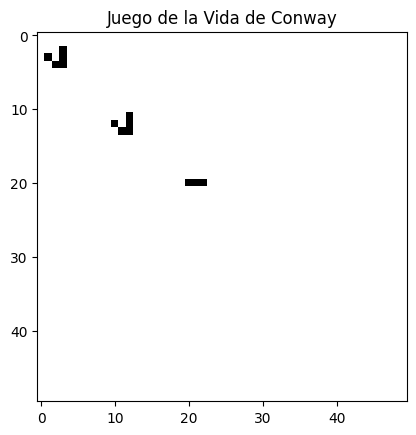

In [25]:
#Tamaño del tablero
rows = 50
cols = 50

#Crear tablero vacío
initial = np.zeros((rows, cols), dtype=int)

#Insertar patrón
initial[1:4, 1:4] = glider()

initial[10:13, 10:13] = glider()

initial[20:21, 20:23] = blinker()

#Crear juego
game = GameOfLife(rows, cols, initial_state=initial)

#Crear figura
fig, ax = plt.subplots()

#Mostrar estado inicial
img = ax.imshow(game.get_state(), cmap="binary")

#Función de actualización
def update(frame):

    game.step()

    img.set_data(game.get_state())

    return [img]

#Crear animación
ani = animation.FuncAnimation(
    fig,
    update,
    frames=100,
    interval=100,
    blit=True
)

plt.title("Juego de la Vida de Conway")

plt.show()

ani.save("game_of_life.gif", writer="pillow")

### Animación del Gráfico:

In [26]:
from IPython.display import Image

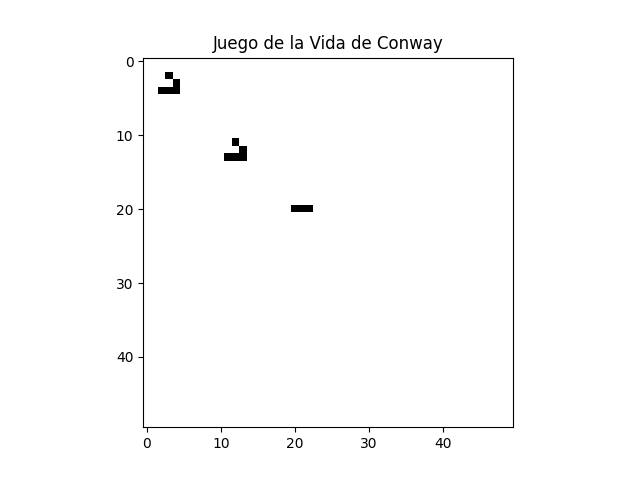

In [27]:
Image(filename="game_of_life.gif")

## Benchmark:

### Tamaños:

In [28]:
sizes = [32, 64, 128, 256, 512, 1024]

times = []

iterations = 10

### Comparación de Tiempos:

In [29]:
for size in sizes:

    game = GameOfLife(size, size)

    start = time.perf_counter()

    for _ in range(iterations):
        game.step()

    end = time.perf_counter()

    avg_time = (end - start) / iterations

    times.append(avg_time)

    print(f"{size}x{size}: {avg_time:.6f} segundos")

32x32: 0.009083 segundos
64x64: 0.015446 segundos
128x128: 0.055732 segundos
256x256: 0.239858 segundos
512x512: 0.911978 segundos
1024x1024: 3.752434 segundos


### Gráfica de Rendimiento:

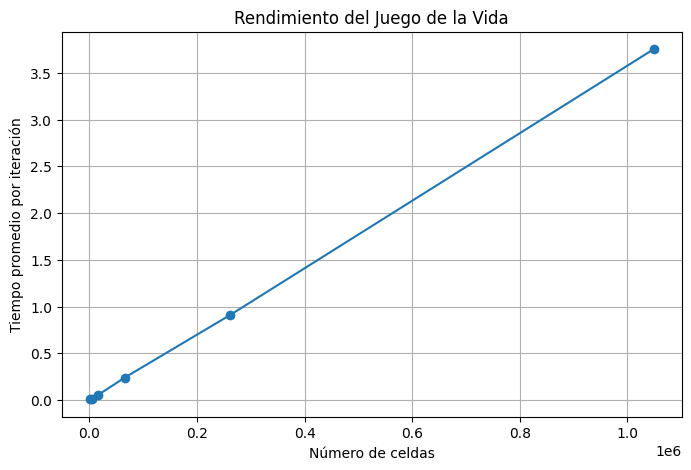

In [30]:
cells = [s * s for s in sizes]

plt.figure(figsize=(8,5))

plt.plot(cells, times, marker='o')

plt.xlabel("Número de celdas")
plt.ylabel("Tiempo promedio por iteración")

plt.title("Rendimiento del Juego de la Vida")

plt.grid(True)

plt.show()

### Curvas Teóricas:

In [31]:
n = np.array(cells)

#O(n)

O_n = n / n.max() * max(times)

#O(n log n)

O_nlogn = n * np.log2(n)
O_nlogn = O_nlogn / O_nlogn.max() * max(times)

#O(n²)

O_n2 = n**2
O_n2 = O_n2 / O_n2.max() * max(times)

### Comparación Experimental vs. Teórica:

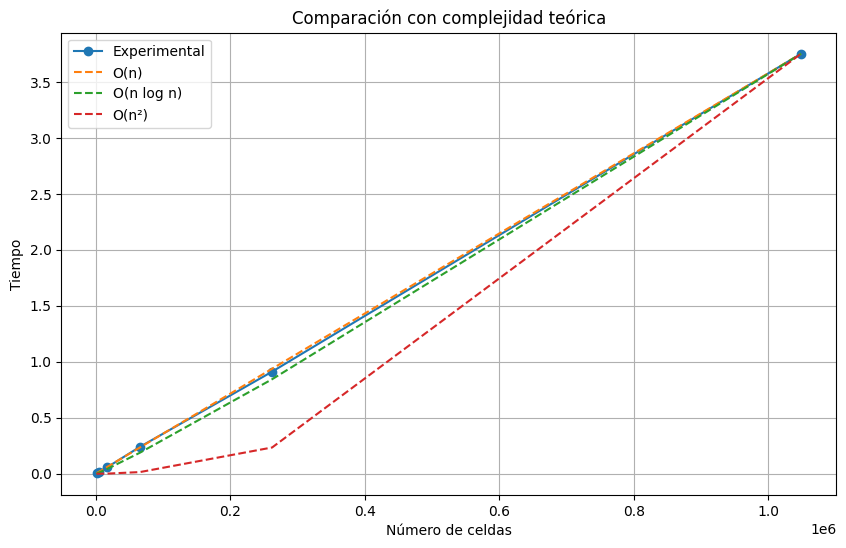

In [32]:
plt.figure(figsize=(10,6))

plt.plot(n, times, 'o-', label='Experimental')

plt.plot(n, O_n, '--', label='O(n)')
plt.plot(n, O_nlogn, '--', label='O(n log n)')
plt.plot(n, O_n2, '--', label='O(n²)')

plt.xlabel("Número de celdas")
plt.ylabel("Tiempo")

plt.title("Comparación con complejidad teórica")

plt.legend()

plt.grid(True)

plt.show()

### Visualización log-log:

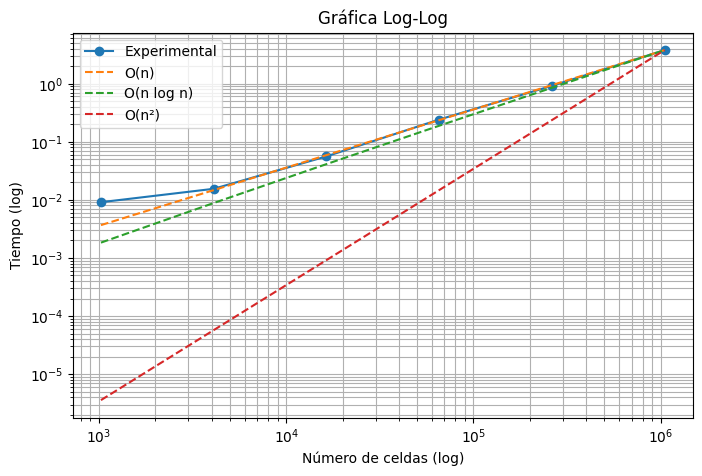

In [33]:
plt.figure(figsize=(8,5))

plt.loglog(n, times, 'o-', label='Experimental')

plt.loglog(n, O_n, '--', label='O(n)')
plt.loglog(n, O_nlogn, '--', label='O(n log n)')
plt.loglog(n, O_n2, '--', label='O(n²)')

plt.xlabel("Número de celdas (log)")
plt.ylabel("Tiempo (log)")

plt.title("Gráfica Log-Log")

plt.legend()

plt.grid(True, which="both")

plt.show()